In [39]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
class BollingerBandTrailingBacktester:
    def __init__(self, symbol, MA, start, end, std_dev=2, exit_threshold=0.02, trail_percentage=0.05):
        """初始化參數"""
        self.symbol = symbol  # 股票代碼
        self.MA = MA  # 移動平均線週期
        self.start = start  # 開始日期
        self.end = end  # 結束日期
        self.std_dev = std_dev  # 標準差倍數
        self.exit_threshold = exit_threshold  # 自動平倉閾值
        self.trail_percentage = trail_percentage  # 移動止盈/止損百分比
        self.results = None
        self.get_data()

    def get_data(self):
        """獲取並處理數據"""
        df = yf.download(self.symbol, start=self.start, end=self.end)
        if df.empty:
            raise ValueError(f"No data retrieved for {self.symbol} from {self.start} to {self.end}")

        # 確保選擇單一 Close 列
        if isinstance(df.columns, pd.MultiIndex):
            close_col = None
            for col in df.columns:
                if 'Close' in col:
                    close_col = col
                    break
            if close_col is None:
                raise ValueError(f"No 'Close' column found in multi-index DataFrame: {df.columns}")
            data = df[close_col].to_frame(name="Close")
        else:
            if 'Close' not in df.columns:
                raise ValueError(f"No 'Close' column found in DataFrame: {df.columns}")
            data = df[['Close']].copy()

        data["returns"] = np.log(data["Close"] / data["Close"].shift(1))  # 計算對數收益率
        data["MA"] = data["Close"].rolling(self.MA).mean()  # 計算移動平均
        data["std"] = data["Close"].rolling(self.MA).std()  # 計算標準差
        data["upper_band"] = data["MA"] + self.std_dev * data["std"]  # 上軌
        data["lower_band"] = data["MA"] - self.std_dev * data["std"]  # 下軌
        data["upper_exit"] = data["upper_band"] * (1 + self.exit_threshold)  # 上軌平倉線
        data["lower_exit"] = data["lower_band"] * (1 - self.exit_threshold)  # 下軌平倉線
        data.dropna(inplace=True)

        if data.empty:
            raise ValueError("No valid data after processing. Check MA period or data availability.")

        self.data2 = data
        return data

    def test_results(self):
        """測試策略並計算回報"""
        data = self.data2.copy().dropna()
        data["position"] = 0  # 初始化持倉
        position = 0  # 當前持倉狀態 (0: 無持倉, 1: 多頭, -1: 空頭)
        entry_price = 0  # 記錄入場價格
        highest_price = 0  # 多頭持倉期間最高價
        lowest_price = float('inf')  # 空頭持倉期間最低價
        entry_idx = 0  # 記錄入場時的索引

        for i in range(1, len(data)):
            price = data["Close"].iloc[i].item()
            ma = data["MA"].iloc[i].item()
            upper_band = data["upper_band"].iloc[i].item()
            lower_band = data["lower_band"].iloc[i].item()
            upper_exit = data["upper_exit"].iloc[i].item()
            lower_exit = data["lower_exit"].iloc[i].item()

            # 更新追蹤價格
            if position == 1:  # 多頭
                highest_price = max(highest_price, price)
                # 移動止損：價格低於最高價的 (1 - trail_percentage)
                stop_loss_price = highest_price * (1 - self.trail_percentage)
                # 移動止盈：價格觸及中軌
                if price <= stop_loss_price or price >= ma:
                    position = 0
                    highest_price = 0
                    entry_price = 0
                # 自動平倉：價格超過上軌平倉線
                elif price >= upper_exit:
                    position = 0
                    highest_price = 0
                    entry_price = 0
            elif position == -1:  # 空頭
                lowest_price = min(lowest_price, price)
                # 移動止損：價格高於最低價的 (1 + trail_percentage)
                stop_loss_price = lowest_price * (1 + self.trail_percentage)
                # 移動止盈：價格觸及中軌
                if price >= stop_loss_price or price <= ma:
                    position = 0
                    lowest_price = float('inf')
                    entry_price = 0
                # 自動平倉：價格低於下軌平倉線
                elif price <= lower_exit:
                    position = 0
                    lowest_price = float('inf')
                    entry_price = 0
            else:
                # 買入信號：價格觸及或低於下軌
                if price <= lower_band and position == 0:
                    position = 1
                    entry_price = price
                    highest_price = price
                    entry_idx = i
                # 賣出信號：價格觸及或高於上軌
                elif price >= upper_band and position == 0:
                    position = -1
                    entry_price = price
                    lowest_price = price
                    entry_idx = i

            data.iloc[i, data.columns.get_loc("position")] = position

        # 計算策略收益
        data["strategy"] = data["returns"] * data["position"].shift(1)
        data.dropna(inplace=True)
        data["returnsbh"] = data["returns"].cumsum().apply(np.exp)  # 買入持有回報
        data["returnsstrategy"] = data["strategy"].cumsum().apply(np.exp)  # 策略回報
        perf = data["returnsstrategy"].iloc[-1]  # 策略總回報
        outperf = perf - data["returnsbh"].iloc[-1]  # 相對買入持有的超額回報
        self.results = data
        return round(perf, 6), round(outperf, 6)

    def plot_results(self):
        """繪製回報曲線"""
        if self.results is None:
            print("請先運行測試")
        else:
            plt.style.use("seaborn-v0_8")
            title = f"{self.symbol} | MA={self.MA} Bollinger Band Strategy (Trailing Stop)"
            self.results[["returnsbh", "returnsstrategy"]].plot(title=title, figsize=(12, 8))
            plt.legend(["Buy & Hold", "Bollinger Band Strategy"], loc="upper left", fontsize=12)
            plt.xlabel("Date", fontsize=12)
            plt.ylabel("Cumulative Returns", fontsize=12)
            plt.show()

    def plot_bollinger_bands(self):
        """繪製布林帶和價格"""
        data = self.data2.copy()
        plt.style.use("seaborn-v0_8")
        plt.figure(figsize=(12, 8))
        plt.plot(data["Close"], label="Close Price", color="blue")
        plt.plot(data["MA"], label=f"MA{self.MA}", color="orange")
        plt.plot(data["upper_band"], label="Upper Band", color="green", linestyle="--")
        plt.plot(data["lower_band"], label="Lower Band", color="red", linestyle="--")
        plt.plot(data["upper_exit"], label="Upper Exit", color="purple", linestyle=":")
        plt.plot(data["lower_exit"], label="Lower Exit", color="brown", linestyle=":")
        plt.legend(loc="upper left", fontsize=12)
        plt.title(f"{self.symbol} Price with Bollinger Bands (MA{self.MA})", fontsize=15)
        plt.xlabel("Date", fontsize=12)
        plt.ylabel("Price", fontsize=12)
        plt.show()

    def plot_bollinger_with_position(self, year=None):
        """繪製布林帶和持倉狀態"""
        if self.results is None:
            print("請先運行測試")
        else:
            data = self.results.copy()
            plt.style.use("seaborn-v0_8")
            if year:
                data = data.loc[str(year)]
            fig, ax1 = plt.subplots(figsize=(12, 8))
            ax1.plot(data.index, data["Close"], label="Close Price", color="blue")
            ax1.plot(data.index, data["MA"], label=f"MA{self.MA}", color="orange")
            ax1.plot(data.index, data["upper_band"], label="Upper Band", color="green", linestyle="--")
            ax1.plot(data.index, data["lower_band"], label="Lower Band", color="red", linestyle="--")
            ax1.set_xlabel("Date", fontsize=12)
            ax1.set_ylabel("Price", fontsize=12, color="blue")
            ax1.tick_params(axis="y", labelcolor="blue")
            ax1.legend(loc="upper left", fontsize=12)
            ax2 = ax1.twinx()
            ax2.plot(data.index, data["position"], label="Position", color="black", linestyle="-")
            ax2.set_ylabel("Position", fontsize=12, color="black")
            ax2.tick_params(axis="y", labelcolor="black")
            ax2.legend(loc="upper right", fontsize=12)
            plt.title(f"{self.symbol} - Bollinger Bands (MA{self.MA}) with Position", fontsize=15)
            plt.show()

In [42]:
tester=BollingerBandBacktester("NVDA",20,"2023-06-23","2025-06-23")

/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_27119/4192470101.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.symbol, start=self.start, end=self.end)
[*********************100%***********************]  1 of 1 completed


In [44]:
tester.test_results()

(1.698377, -1.55014)

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26519 (\N{CJK UNIFIED IDEOGRAPH-6797}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24118 (\N{CJK UNIFIED IDEOGRAPH-5E36}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30053 (\N{CJK UNIFIED IDEOGRAPH-7565}) missing from font(s) Arial.
  fig.canvas.print_fig

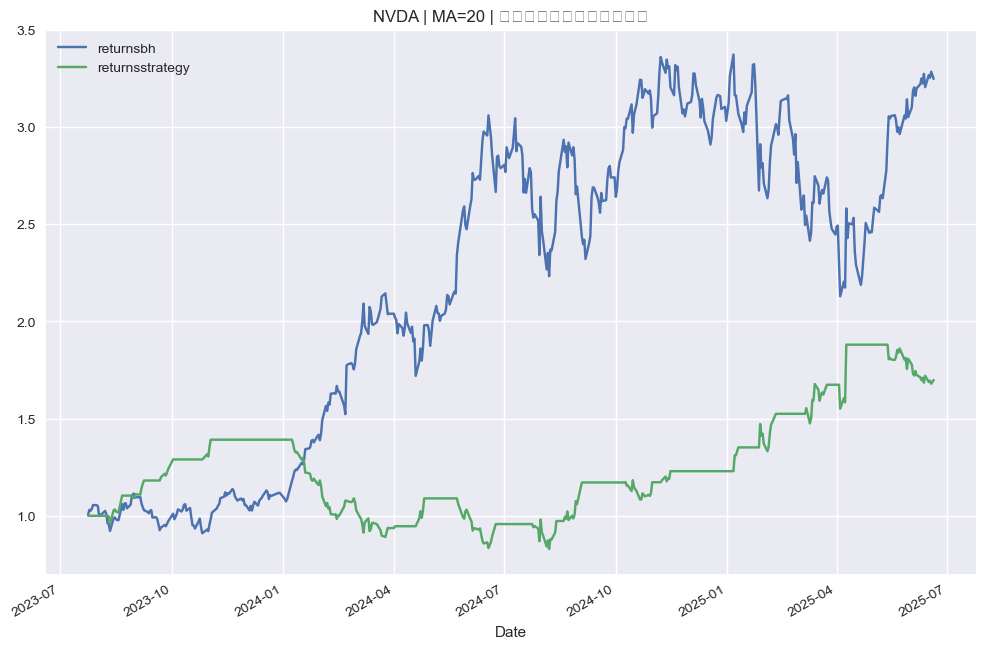

In [45]:
tester.plot_results()

In [46]:
tester.plot_bollinger_with_position()

AttributeError: 'BollingerBandBacktester' object has no attribute 'plot_bollinger_with_position'

In [32]:
tester.plot_bollinger_bands()

AttributeError: 'BollingerBandBacktester' object has no attribute 'plot_bollinger_bands'

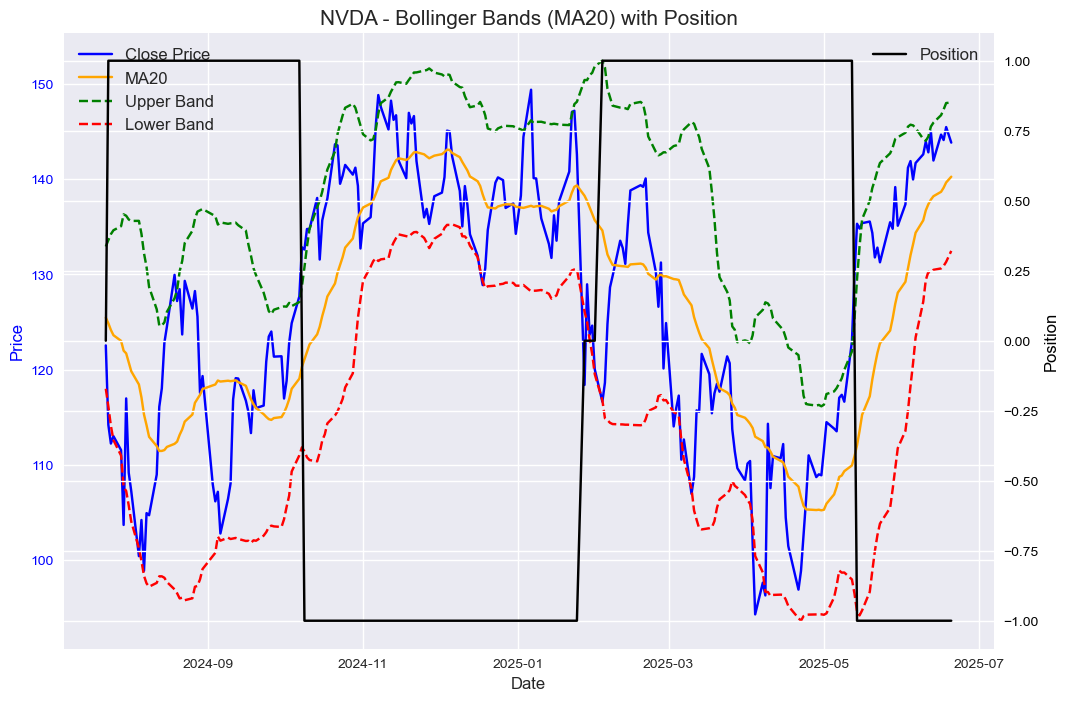

In [28]:
tester.plot_bollinger_with_position()